# Cardiovascular Disease Prediction
### COM763 Task 1 — Machine Learning Pipeline
---

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print('Libraries imported successfully')

Libraries imported successfully


## 2. Load Dataset

`sep=';'` is used because the Kaggle Cardiovascular dataset uses semicolons instead of commas to separate values.

In [4]:
df = pd.read_csv('cardio_train.csv', sep=';')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
print('Summary statistics:')
df.describe()

Summary statistics:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print('Data types:')
df.dtypes

Data types:


,0
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


## 3. Preprocessing

### 3.1 Convert Age
In a real-world healthcare setting, doctors diagnose risk based on years, not days. Converting age aligns the feature with clinical standards.

In [7]:
df['age'] = (df['age'] / 365).round().astype(int)
print('Age converted from days to years')
print(f'Age range: {df["age"].min()} - {df["age"].max()} years')

Age converted from days to years
Age range: 30 - 65 years


### 3.2 Check Missing Values
Checking for missing values is necessary because mathematical models cannot perform operations on non-existent data.

In [8]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### 3.3 Imputation
Using median imputation to handle any missing values robustly against outliers.

In [9]:
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print('Median imputation applied')

Median imputation applied


## 4. Exploratory Data Analysis

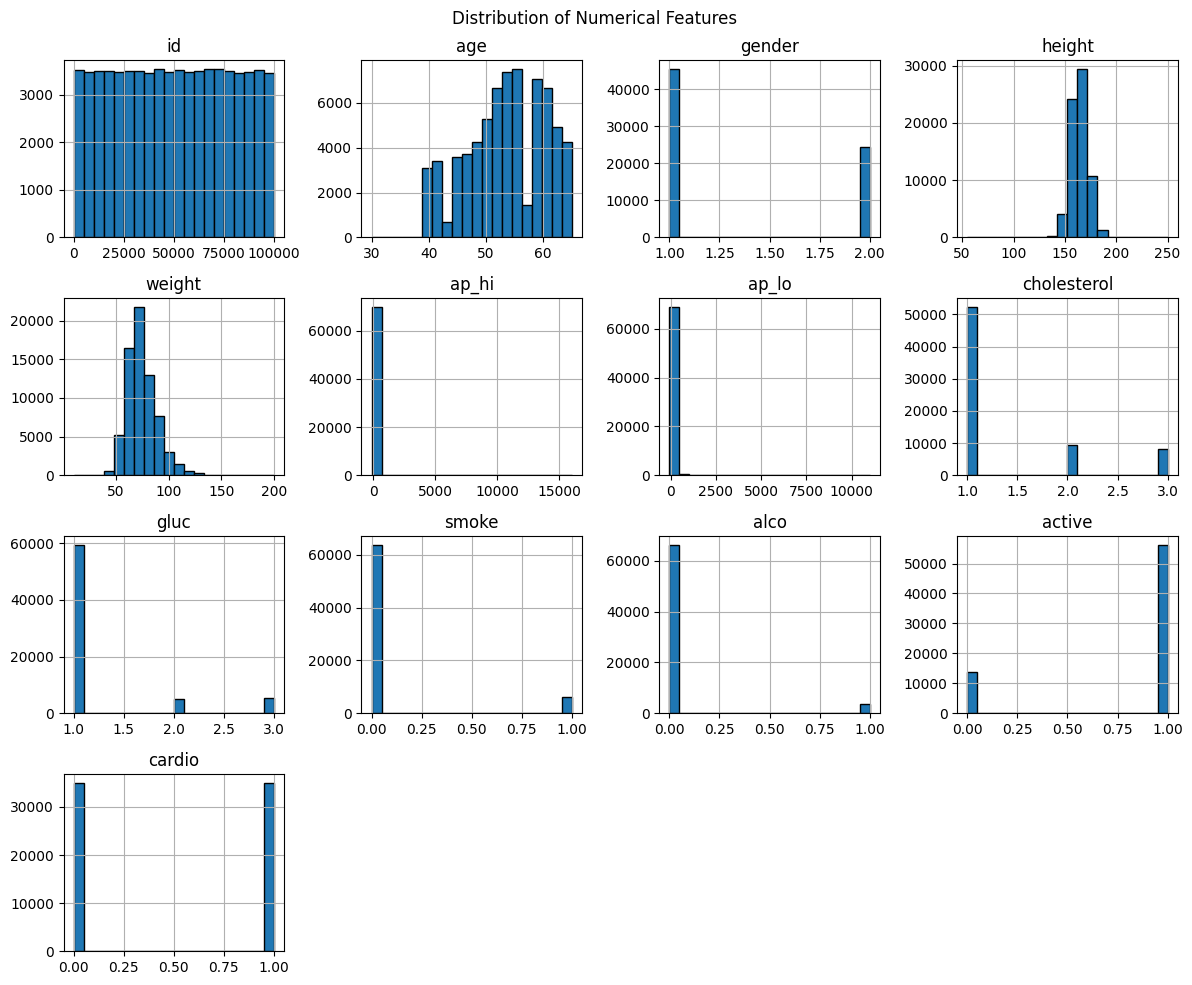

In [10]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

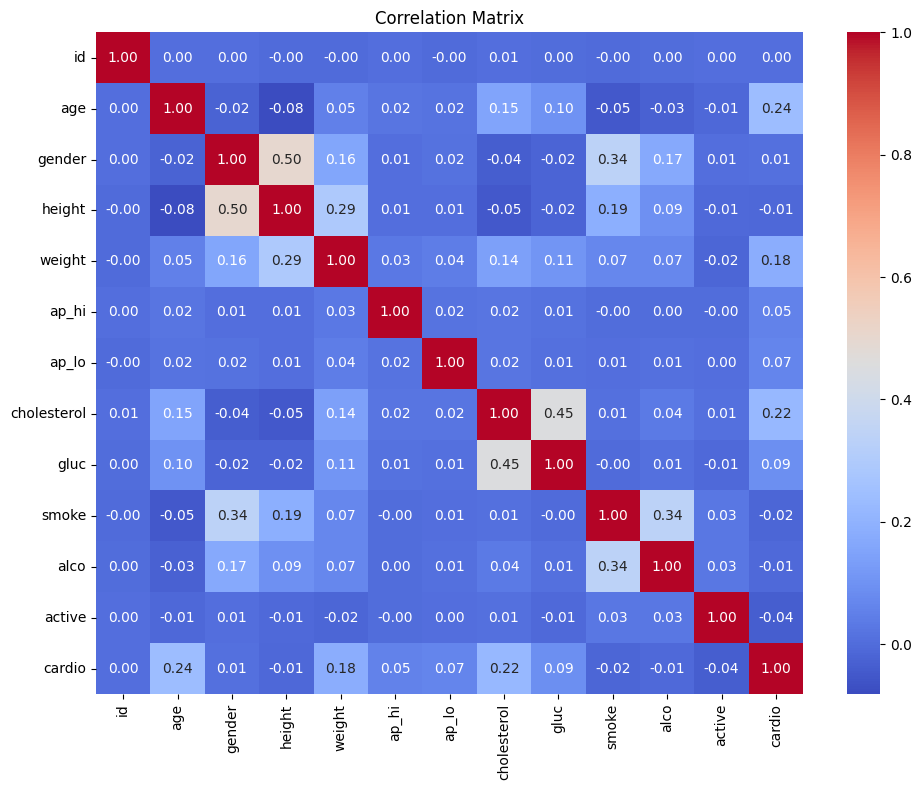

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

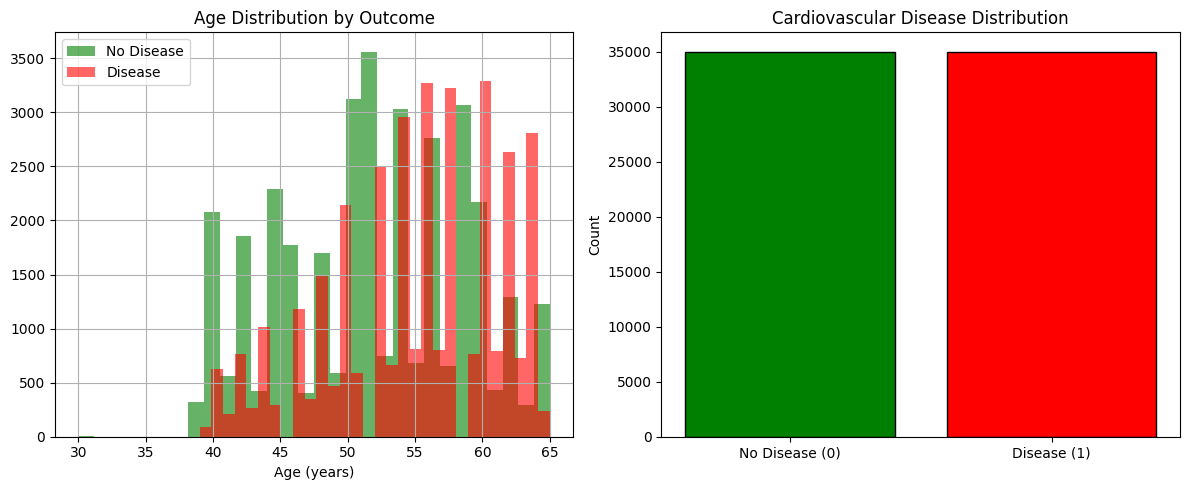

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution by outcome
df[df['cardio']==0]['age'].hist(ax=axes[0], bins=30, alpha=0.6, color='green', label='No Disease')
df[df['cardio']==1]['age'].hist(ax=axes[0], bins=30, alpha=0.6, color='red', label='Disease')
axes[0].set_title('Age Distribution by Outcome')
axes[0].set_xlabel('Age (years)')
axes[0].legend()

# Target distribution
counts = df['cardio'].value_counts()
axes[1].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['green', 'red'], edgecolor='black')
axes[1].set_title('Cardiovascular Disease Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Outlier Handling

Using the IQR method to detect and remove outliers. A data point is considered an outlier if it falls below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

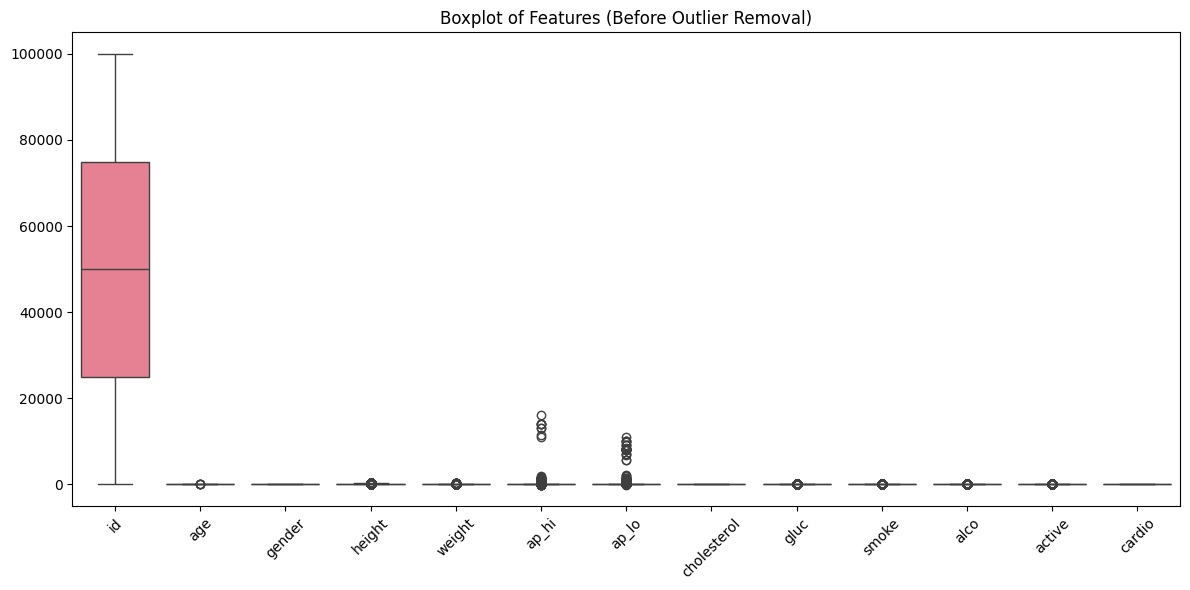

In [13]:
# Boxplot before outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_imputed)
plt.title('Boxplot of Features (Before Outlier Removal)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# IQR outlier removal
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1

outlier_condition = ((df_imputed < (Q1 - 1.5 * IQR)) | (df_imputed > (Q3 + 1.5 * IQR)))
df_no_outliers = df_imputed[~outlier_condition.any(axis=1)].copy()

print(f'Original shape:  {df_imputed.shape}')
print(f'After removal:   {df_no_outliers.shape}')
print(f'Rows removed:    {len(df_imputed) - len(df_no_outliers)}')

Original shape:  (70000, 13)
After removal:   (38023, 13)
Rows removed:    31977


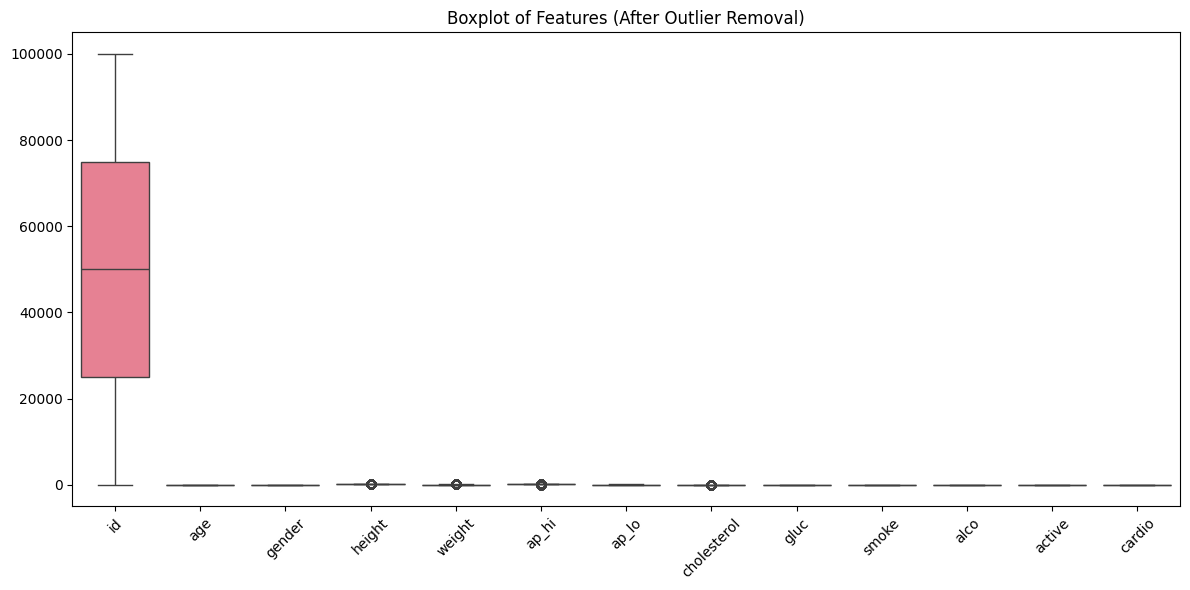

In [15]:
# Boxplot after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_no_outliers)
plt.title('Boxplot of Features (After Outlier Removal)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Creating two new features:
- **BMI**: calculated from weight and height, a standard clinical measure of body composition
- **Age_Category** and **BMI_Category**: categorical groupings that align with clinical thresholds

In [16]:
df_no_outliers = df_no_outliers.copy()

def categorize_age(age):
    if age < 21:
        return 'Young'
    elif age < 35:
        return 'Adult'
    else:
        return 'Middle_Aged'

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

# Calculate BMI
df_no_outliers.loc[:, 'BMI'] = df_no_outliers['weight'] / ((df_no_outliers['height'] / 100) ** 2)

# Add category features
df_no_outliers.loc[:, 'Age_Category'] = df_no_outliers['age'].apply(categorize_age).astype('category')
df_no_outliers.loc[:, 'BMI_Category'] = df_no_outliers['BMI'].apply(categorize_bmi).astype('category')

print('New features added:')
df_no_outliers[['age', 'Age_Category', 'BMI', 'BMI_Category']].head(10)

New features added:


,age,Age_Category,BMI,BMI_Category
0,50.0,Middle_Aged,21.967120,Normal
1,55.0,Middle_Aged,34.927679,Obese
3,48.0,Middle_Aged,28.710479,Overweight
6,61.0,Middle_Aged,37.729725,Obese
8,48.0,Middle_Aged,28.440955,Overweight
10,62.0,Middle_Aged,28.010224,Overweight
11,52.0,Middle_Aged,20.047446,Normal
13,54.0,Middle_Aged,31.244993,Obese
20,54.0,Middle_Aged,31.239414,Obese
21,59.0,Middle_Aged,27.993022,Overweight


## 7. Encoding Categorical Variables

In [17]:
from sklearn.preprocessing import LabelEncoder

# Label encoding
le_age = LabelEncoder()
le_bmi = LabelEncoder()
df_no_outliers.loc[:, 'Age_Category_Label'] = le_age.fit_transform(df_no_outliers['Age_Category'])
df_no_outliers.loc[:, 'BMI_Category_Label'] = le_bmi.fit_transform(df_no_outliers['BMI_Category'])

# One-hot encoding
df_encoded = pd.get_dummies(df_no_outliers, columns=['Age_Category', 'BMI_Category'], prefix=['Age', 'BMI'])

print('Encoding complete. Shape:', df_encoded.shape)
df_encoded.head()

Encoding complete. Shape: (38023, 21)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,active,cardio,BMI,Age_Category_Label,BMI_Category_Label,Age_Middle_Aged,BMI_Normal,BMI_Obese,BMI_Overweight,BMI_Underweight
0,0.0,50.0,2.0,168.0,62.0,110.0,80.0,1.0,1.0,0.0,...,1.0,0.0,21.967120,0,0,True,True,False,False,False
1,1.0,55.0,1.0,156.0,85.0,140.0,90.0,3.0,1.0,0.0,...,1.0,1.0,34.927679,0,1,True,False,True,False,False
3,3.0,48.0,2.0,169.0,82.0,150.0,100.0,1.0,1.0,0.0,...,1.0,1.0,28.710479,0,2,True,False,False,True,False
6,9.0,61.0,1.0,157.0,93.0,130.0,80.0,3.0,1.0,0.0,...,1.0,0.0,37.729725,0,1,True,False,True,False,False
8,13.0,48.0,1.0,158.0,71.0,110.0,70.0,1.0,1.0,0.0,...,1.0,0.0,28.440955,0,2,True,False,False,True,False


## 8. Feature Scaling

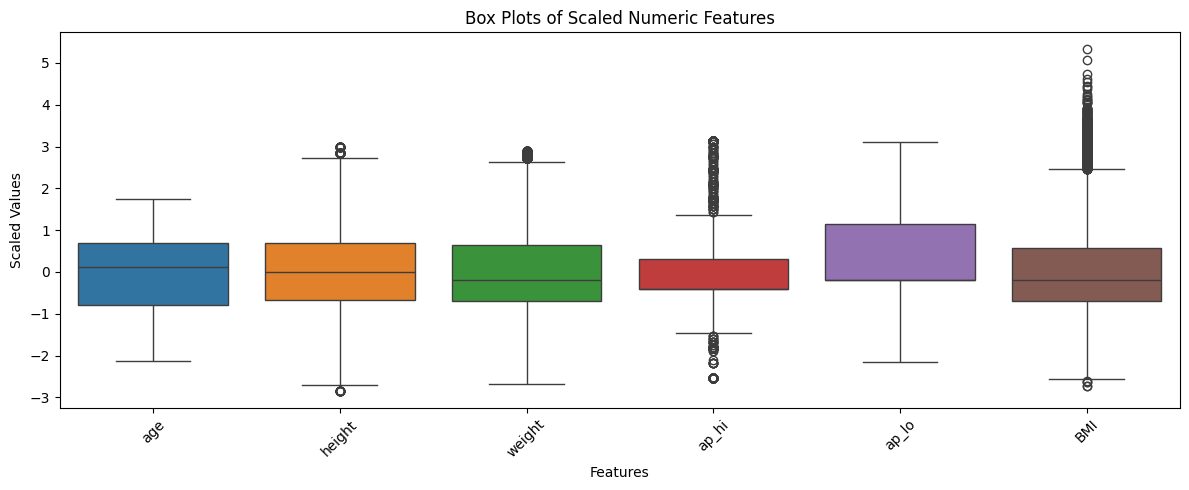

In [18]:
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI']

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])

# Boxplot after scaling
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_scaled[numeric_columns])
plt.title('Box Plots of Scaled Numeric Features')
plt.xlabel('Features')
plt.ylabel('Scaled Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Train / Test Split

In [19]:
# Drop id if present
if 'id' in df_no_outliers.columns:
    df_no_outliers = df_no_outliers.drop(columns=['id'])

# Use clean numeric features for modelling
feature_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']

X = df_no_outliers[feature_cols]
y = df_no_outliers['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape}')
print(f'Test set:      {X_test.shape}')

Training set:  (30418, 12)
Test set:      (7605, 12)


## 10. Build Pipeline & Train Logistic Regression Model

A pipeline ensures that preprocessing (imputation and scaling) is applied consistently to both training and test data, preventing data leakage.

In [20]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


## 11. Model Evaluation

In [21]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print('=' * 40)
print(f'Accuracy : {accuracy:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print('=' * 40)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Accuracy : 0.7328
ROC-AUC  : 0.7952

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.71      0.83      0.77      4030
     Disease       0.76      0.63      0.69      3575

    accuracy                           0.73      7605
   macro avg       0.74      0.73      0.73      7605
weighted avg       0.74      0.73      0.73      7605



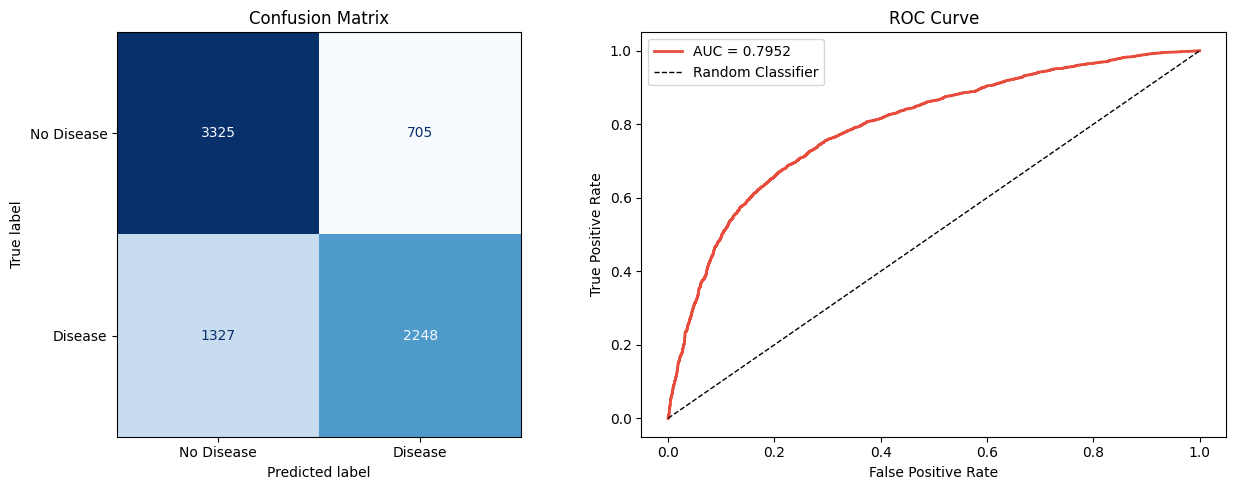

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Feature Importance (Logistic Regression Coefficients)

The coefficients of the logistic regression model indicate how strongly each feature influences the prediction. Positive values increase the risk of cardiovascular disease; negative values decrease it.

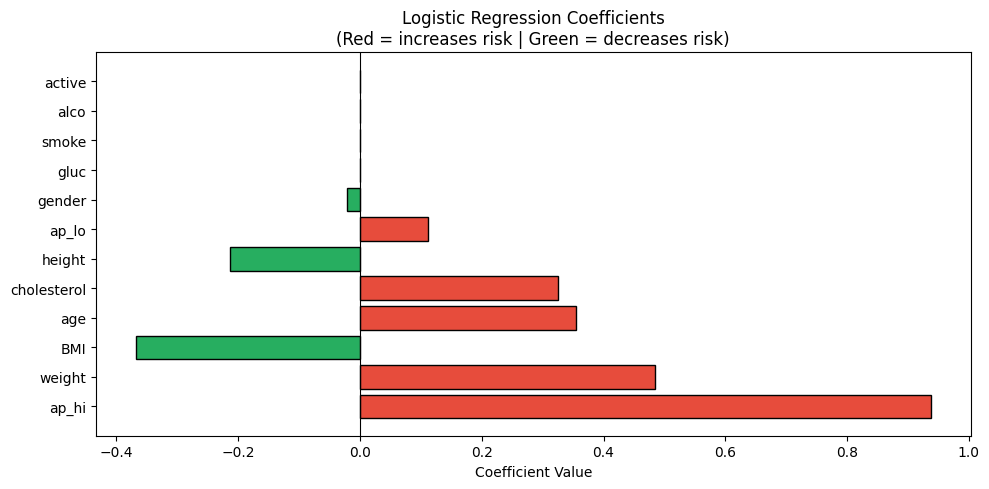

    Feature  Coefficient
      ap_hi     0.937646
     weight     0.485077
        BMI    -0.368405
        age     0.354201
cholesterol     0.325083
     height    -0.213960
      ap_lo     0.112145
     gender    -0.021958
       gluc     0.000000
      smoke     0.000000
       alco     0.000000
     active     0.000000


In [23]:
coefficients = pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': coefficients})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#27ae60' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red = increases risk | Green = decreases risk)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## 13. Save Trained Model

In [24]:
joblib.dump(pipeline, 'cardio_logistic_model.pkl')

print('Model saved to: cardio_logistic_model.pkl')
print('-' * 40)
print(f'Accuracy : {accuracy:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print('Pipeline: SimpleImputer → StandardScaler → LogisticRegression')

Model saved to: cardio_logistic_model.pkl
----------------------------------------
Accuracy : 0.7328
ROC-AUC  : 0.7952
Pipeline: SimpleImputer → StandardScaler → LogisticRegression
